<a href="https://colab.research.google.com/github/hamedali70/Hamed_rl_sem8/blob/main/RL_Exp_08_(final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment No 08

##Hamed Ali / 15 / 211A013

In [1]:
print("Hamed Ali / 15 / 211A013")
!pip install gymnasium[atari]

Hamed Ali / 15 / 211A013


In [2]:
print("Hamed Ali / 15 / 211A013")
!pip install ale.py

Hamed Ali / 15 / 211A013


In [3]:
print("Hamed Ali / 15 / 211A013")
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

Hamed Ali / 15 / 211A013


In [4]:
print("Hamed Ali / 15 / 211A013")
class DQN(nn.Module):
  def __init__(self, input_shape, n_actions):
    super().__init__()
    self.net = nn.Sequential(
      nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
      nn.ReLU(),
      nn.Conv2d(32, 64, kernel_size=4, stride=2),
      nn.ReLU(),
      nn.Conv2d(64, 64, kernel_size=3, stride=1),
      nn.ReLU(),
      nn.Flatten(),
      nn.Linear(3136, 512),
      nn.ReLU(),
      nn.Linear(512, n_actions)
    )

  def forward(self, x):
    return self.net(x / 255.0)

Hamed Ali / 15 / 211A013


In [5]:
print("Hamed Ali / 15 / 211A013")
class ReplayBuffer:
  def __init__(self, capacity):
    self.buffer = deque(maxlen=capacity)

  def push(self, state, action, reward, next_state, done):
    self.buffer.append((state, action, reward, next_state, done))

  def sample(self, batch_size):
    batch = random.sample(self.buffer, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    return (
    np.array(states),
    np.array(actions),
    np.array(rewards),
    np.array(next_states),
    np.array(dones)
    )

  def __len__(self):
    return len(self.buffer)

Hamed Ali / 15 / 211A013


In [6]:
print("Hamed Ali / 15 / 211A013")
BATCH_SIZE = 32
GAMMA = 0.99
LR = 1e-4
BUFFER_SIZE = 100000
EPSILON_START = 1.0
EPSILON_END = 0.1
EPSILON_DECAY = 100000
TARGET_UPDATE = 1000

Hamed Ali / 15 / 211A013


##  Environment Setup

In [7]:
print("Hamed Ali / 15 / 211A013")
import ale_py

env = gym.make("ALE/Pong-v5", render_mode=None)
n_actions = env.action_space.n

# Example input shape for Atari (stacked frames)
input_shape = (4, 84, 84)

Hamed Ali / 15 / 211A013


## Initialize Network

In [8]:
print("Hamed Ali / 15 / 211A013")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

policy_net = DQN(input_shape, n_actions).to(device)
target_net = DQN(input_shape, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
replay_buffer = ReplayBuffer(BUFFER_SIZE)

Hamed Ali / 15 / 211A013


## Epsilon Greedy Policy

In [9]:
print("Hamed Ali / 15 / 211A013")
def epsilon_by_frame(frame_idx):
    return EPSILON_END + (EPSILON_START - EPSILON_END) * \
           np.exp(-1. * frame_idx / EPSILON_DECAY)

def select_action(state, epsilon):
    if random.random() < epsilon:
        return random.randrange(n_actions)
    else:
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        q_values = policy_net(state)
        return q_values.max(1)[1].item()

Hamed Ali / 15 / 211A013


## Training Setup

In [10]:
print("Hamed Ali / 15 / 211A013")
def train_step():
  if len(replay_buffer) < BATCH_SIZE:
      return
  states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)

  states = torch. tensor(states, dtype=torch. float32).to(device)
  next_states = torch.tensor(next_states, dtype=torch. float32).to(device)
  actions = torch.tensor(actions).unsqueeze(1).to(device)
  rewards = torch.tensor(rewards).to(device)
  dones = torch. tensor(dones).to(device)

  q_values = policy_net(states).gather(1, actions).squeeze(1)
  next_q_values = target_net(next_states).max(1) [0]

  expected_q = rewards + GAMMA * next_q_values * (1 - dones.float())

  loss = nn.MSELoss() (q_values, expected_q.detach())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Hamed Ali / 15 / 211A013


In [11]:
print("Hamed Ali / 15 / 211A013")
env = gym.make("ALE/Pong-v5", render_mode="rgb_array")

Hamed Ali / 15 / 211A013


In [12]:
print("Hamed Ali / 15 / 211A013")
env.reset ()

Hamed Ali / 15 / 211A013


(array([[[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [109, 118,  43],
         [109, 118,  43],
         [109, 118,  43]],
 
        [[109, 118,  43],
         [109, 118,  43],
         [109, 118,  43],
         ...,
         [109, 118,  43],
         [109, 118,  43],
         [109, 118,  43]],
 
        [[109, 118,  43],
         [109, 118,  43],
         [109, 118,  43],
         ...,
         [109, 118,  43],
         [109, 118,  43],
         [109, 118,  43]],
 
        ...,
 
        [[ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24],
         ...,
         [ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24]],
 
        [[ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24],
         ...,
         [ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24]],
 
        [[ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24],
         ...,
         [ 53,  95,  24],
  

Hamed Ali / 15 / 211A013


array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [109, 118,  43],
        [109, 118,  43],
        [109, 118,  43]],

       [[109, 118,  43],
        [109, 118,  43],
        [109, 118,  43],
        ...,
        [109, 118,  43],
        [109, 118,  43],
        [109, 118,  43]],

       [[109, 118,  43],
        [109, 118,  43],
        [109, 118,  43],
        ...,
        [109, 118,  43],
        [109, 118,  43],
        [109, 118,  43]],

       ...,

       [[ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24],
        ...,
        [ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24]],

       [[ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24],
        ...,
        [ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24]],

       [[ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24],
        ...,
        [ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24]]], dtype=uint8)
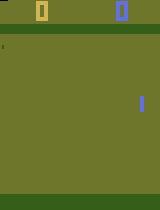

In [13]:
print("Hamed Ali / 15 / 211A013")
env.reset() # Ensure environment is reset before rendering
env.render()

## Training Loop

In [14]:
print("Hamed Ali / 15 / 211A013")
# Redefine train_step to fix the RuntimeError with boolean tensors
def train_step():
  if len(replay_buffer) < BATCH_SIZE:
      return
  states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)

  states = torch.tensor(states, dtype=torch.float32).to(device)
  next_states = torch.tensor(next_states, dtype=torch.float32).to(device)
  actions = torch.tensor(actions).unsqueeze(1).to(device)
  # Fix: Convert rewards to float32
  rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
  # Fix: Convert boolean 'dones' to float tensor before arithmetic operations
  dones = torch.tensor(dones, dtype=torch.float32).to(device)

  q_values = policy_net(states).gather(1, actions).squeeze(1)
  next_q_values = target_net(next_states).max(1)[0]

  expected_q = rewards + GAMMA * next_q_values * (1 - dones)

  loss = nn.MSELoss()(q_values, expected_q.detach())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


num_frames = 1000
state, _ = env.reset()
# NOTE: Proper preprocessing (grayscale, resize, frame stack) needed here
state = np.zeros(input_shape) # placeholder

for frame_idx in range(1, num_frames + 1):
  epsilon = epsilon_by_frame(frame_idx)
  action = select_action(state, epsilon)
  next_state, reward, terminated, truncated, _= env.step(action)
  done = terminated or truncated

  next_state = np.zeros(input_shape) # placeholder preprocessing

  replay_buffer.push(state, action, reward, next_state, done)
  state = next_state

  train_step()

  if frame_idx % TARGET_UPDATE == 0:
    target_net.load_state_dict(policy_net.state_dict())

  if done:
    state, _= env.reset ()
    state = np.zeros(input_shape)

Hamed Ali / 15 / 211A013
